# Project data exploration II -
## plotting categorical plot and incorporating other data

---


We will continue to work with the dataset that your group is consider for the term project. In this notebook we will create some plot using the Seaborn module and the different categorical plots we practiced in class. Additionally, we will explore the idea of working with other datasets in addition to the one you originally selected to strengthen your argument.

Group name: DART (Diabetes Analytics & Research Team)
Created by Anh Tran (015621450), Willy Tang (SJSU ID), Jacob Atanacio (SJSU ID), Aziza  (SJSU ID)
Last updated: 3/26/2026

### Q1: How clean is your data?  
Do you have formatting concerns, null values, inconsistent data, etc... If so, explain what cleaning or reformating you have to do and how you plan to approach this cleaning steps.

In [1]:
### Importing libraries
import numpy as np
import pandas as pd

# plotly libraries
from plotly.offline import init_notebook_mode, iplot, plot
import plotly as py
init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns

# matplotlib
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv('../diabetes_dataset.csv')
data.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [4]:
data.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


For our dataset, we checked for null count, formatting, and data types of each columns to ensure that we have clean and well organized dataset. From what we observed, there seems to be no null values and the data types are all the correct types.

### Q2: Create a categorical plot
Come up with a unique question that can be answer using a categorical plot from the sns module

#### Question:
Are there differences in measuring fasting glucose and prandial glucose for determining blood sugar levels, a factor considered for diabetes?

       diabetes_stage               measure  glucose
0              Type 2       glucose_fasting      136
1         No Diabetes       glucose_fasting       93
2              Type 2       glucose_fasting      118
3              Type 2       glucose_fasting      139
4              Type 2       glucose_fasting      137
...               ...                   ...      ...
199995   Pre-Diabetes  glucose_postprandial      109
199996   Pre-Diabetes  glucose_postprandial      146
199997    No Diabetes  glucose_postprandial      132
199998   Pre-Diabetes  glucose_postprandial      117
199999   Pre-Diabetes  glucose_postprandial      142

[200000 rows x 3 columns]


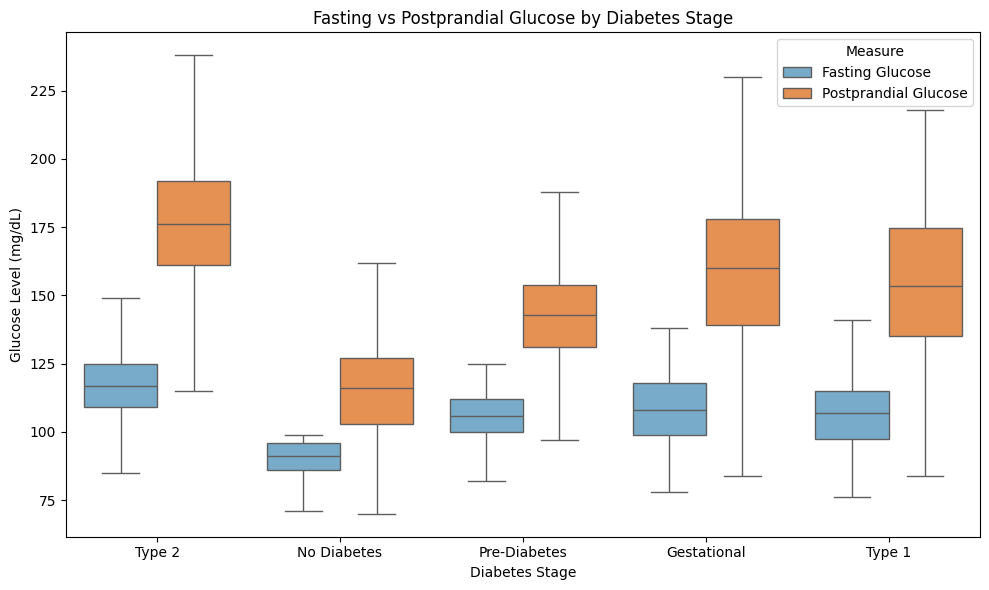

In [12]:


#Get just the columns for glucose levels during fasting and postprandial, as well as the diabetes_stages
glucose_df = data[["glucose_fasting", "glucose_postprandial", "diabetes_stage"]].dropna().copy()
#Conver thte glucose df into a long format so we can see the diabetees stage along with its measure of erither glucose fasting or glucose post prandial and their corresponding glucose level
long_df = glucose_df.melt(
    id_vars="diabetes_stage",
    value_vars=["glucose_fasting", "glucose_postprandial"],
    var_name="measure",
    value_name="glucose"
)
print(long_df)
#Replace the value so that it looks more clean rather than having the "_" so we can use this for the legend bvox
long_df["measure"] = long_df["measure"].replace({
    "glucose_fasting": "Fasting Glucose",
    "glucose_postprandial": "Postprandial Glucose"
})


plt.figure(figsize=(10, 6))
sns.boxplot(
    data=long_df,
    x="diabetes_stage",
    y="glucose",
    hue="measure",
    palette=["#6baed6", "#fd8d3c"],
    showfliers=False
)

plt.title("Fasting vs Postprandial Glucose by Diabetes Stage")
plt.xlabel("Diabetes Stage")
plt.ylabel("Glucose Level (mg/dL)")
plt.legend(title="Measure")
plt.tight_layout()
plt.show()

#### Analysis:
Based on the categorical box plot, we can see teh different measurement in mg/dL of Fasting Glucose and Postprandial Glucose in the five types of diabetes stage. Furtheremore, when looking at an article from Mayo Clinic (https://www.mayoclinic.org/diseases-conditions/diabetes/diagnosis-treatment/drc-20371451), we are able to compare some of these values to ensure its accuracy. For instance, in our plot, people with no diabetes showed low level of Fasting Glucose level under 100 mg/dL, which corresponse with that was mentioned in the article, which stated that "A fasting blood sugar level less than 100 mg/dL (5.6 mmol/L) is normal". In addition, for people with pre-diabetes, a level between 100-125 mg/dL is displayed on the plot and Mayo Clinic mentioned that "A fasting blood sugar level from 100 to 125 mg/dL (5.6 to 6.9 mmol/L) is considered prediabetes." As you can see, the categorical box plot displays accurate analysis that corresponse with what is researched from Mayo Clinic.

### Q3: Come up with a another unique question. This question must use map() or apply()

In [6]:
# Your code here . . .

### Q4: Create an interactive plot
Create an interactive plot using plotly. Your plot can be a previously asked question or a new question, however explain how this interaction strengthen what you want to communicate with your audience.

In [7]:
lifestyle = data.sample(1000)

lifestyle

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
4968,45,Male,Hispanic,Graduate,Upper-Middle,Retired,Current,1,72,4.1,...,62,103,125,136,202,4.78,7.79,25.9,Type 2,1
75875,84,Male,White,Highschool,Lower-Middle,Retired,Never,2,17,8.3,...,56,156,85,94,132,4.06,5.52,35.9,Type 2,1
7283,49,Male,White,Graduate,Lower-Middle,Employed,Never,2,98,6.3,...,61,50,191,134,204,15.11,7.85,43.6,Type 2,1
31031,69,Male,White,Postgraduate,Middle,Employed,Never,2,29,7.0,...,46,159,167,129,224,12.12,8.10,36.6,Type 2,1
93405,31,Male,Other,Highschool,Upper-Middle,Employed,Never,2,193,6.5,...,72,80,95,123,144,2.00,6.42,15.5,Pre-Diabetes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15422,72,Male,Black,Highschool,Middle,Employed,Never,3,123,8.2,...,54,103,160,127,218,8.06,7.62,30.4,Type 2,1
42577,74,Male,Black,Highschool,Low,Employed,Never,3,48,6.4,...,75,96,130,111,164,2.00,6.83,33.7,Type 2,1
36662,60,Female,Hispanic,Graduate,Middle,Retired,Never,1,70,3.7,...,62,160,169,116,192,4.73,7.63,34.1,Type 2,1
80385,45,Female,Black,Graduate,Lower-Middle,Retired,Never,4,128,7.1,...,53,50,94,85,134,11.26,5.12,26.5,No Diabetes,0


In [8]:
lifestyle = lifestyle[["physical_activity_minutes_per_week", "diet_score", "bmi", "diabetes_risk_score", "diagnosed_diabetes"]].sort_values(
    by="diabetes_risk_score", ignore_index=True)

lifestyle

,physical_activity_minutes_per_week,diet_score,bmi,diabetes_risk_score,diagnosed_diabetes
0,252,5.5,19.5,11.0,0
1,216,8.3,24.7,11.6,0
2,178,7.7,24.3,12.0,0
3,429,4.8,24.9,12.2,0
4,279,5.3,20.0,12.5,0
...,...,...,...,...,...
995,13,7.7,25.9,53.8,1
996,99,2.8,39.0,55.0,1
997,17,3.9,29.1,55.5,1
998,54,7.2,29.9,55.5,1


In [9]:
color = list(np.random.choice(range(256), size=3))
print(color)

[178, 144, 67]


In [10]:
lifestyle['activity_bin'] = (lifestyle['physical_activity_minutes_per_week'] // 50) * 50
lifestyle['bmi_bin']      = (lifestyle['bmi'] // 2) * 2
lifestyle['diet_bin']     = (lifestyle['diet_score'] // 1) * 1

df = lifestyle[
    (lifestyle['physical_activity_minutes_per_week'] <= 550) &
    (lifestyle['bmi'] <= 38)
].copy()

MIN_N = 30  

def make_pivot(df, row_col, col_col):
    agg = df.groupby([row_col, col_col])['diagnosed_diabetes'].agg(['mean','count']).reset_index()
    agg = agg[agg['count'] >= MIN_N]
    return agg.pivot(index=row_col, columns=col_col, values='mean')

p_act_bmi  = make_pivot(df, 'bmi_bin',  'activity_bin')   # BMI rows, Activity cols
p_act_diet = make_pivot(df, 'diet_bin', 'activity_bin')   # Diet rows, Activity cols
p_bmi_diet = make_pivot(df, 'diet_bin', 'bmi_bin')        # Diet rows, BMI cols

overall = df['diagnosed_diabetes'].mean()

colorscale = [
    [0.0,  '#1a4a8a'],
    [0.3,  '#378ADD'],
    [0.55, '#f5f0e8'],
    [0.75, '#D85A30'],
    [1.0,  '#7a1a00']
]

def heatmap_trace(pivot, xlab, ylab, name):
    x = [str(int(v) if v == int(v) else v) for v in pivot.columns]
    y = [str(int(v) if v == int(v) else v) for v in pivot.index]
    z = pivot.values.tolist()
    return go.Heatmap(
        x=x, y=y, z=z,
        colorscale=colorscale,
        zmin=0.3, zmax=0.85,
        colorbar=dict(
            title=dict(text='Diabetes rate', side='right'),
            tickformat='.0%',
            len=0.85
        ),
        hovertemplate=(
            xlab + ': %{x}<br>' +
            ylab + ': %{y}<br>' +
            'Diabetes rate: %{z:.1%}<extra>' + name + '</extra>'
        ),
        name=name,
        showscale=True
    )

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        'Activity × BMI',
        'Activity × Diet Score',
        'BMI × Diet Score'
    ),
    horizontal_spacing=0.10
)

fig.add_trace(heatmap_trace(p_act_bmi,  'Activity (min/wk)', 'BMI',        'Activity × BMI'),  row=1, col=1)
fig.add_trace(heatmap_trace(p_act_diet, 'Activity (min/wk)', 'Diet score', 'Activity × Diet'), row=1, col=2)
fig.add_trace(heatmap_trace(p_bmi_diet, 'BMI',               'Diet score', 'BMI × Diet'),       row=1, col=3)

fig.data[1].showscale = False
fig.data[2].showscale = False

fig.update_layout(
    title=dict(
        text='Combined Lifestyle Factor Influence on Diabetes Likelihood',
        font=dict(size=16)
    ),
    height=480,
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    margin=dict(t=80, b=60, l=60, r=80)
)

fig.update_xaxes(title_text='Activity (min/week)', row=1, col=1)
fig.update_yaxes(title_text='BMI',                 row=1, col=1)
fig.update_xaxes(title_text='Activity (min/week)', row=1, col=2)
fig.update_yaxes(title_text='Diet score',          row=1, col=2)
fig.update_xaxes(title_text='BMI',                 row=1, col=3)
fig.update_yaxes(title_text='Diet score',          row=1, col=3)

fig.show()

From this plot we can see that physical activity is the most actionable protective factor where individuals exercising 300+ minutes per week consistently show diabetes rates 15–20 percentage points lower than sedentary individuals, regardless of diet quality. BMI is the strongest single risk driver in the dataset, with diagnosis rates climbing steadily from 46% at healthy weights to over 74% at high BMI, and this elevated risk persists even among people with good diet scores. Diet score has the weakest independent influence of the three, suggesting that physical activity and weight management are far more critical levers for reducing diabetes likelihood than dietary choices alone.

## Q5: Additional datasets and data processing
For the questions below you do not need to do the plotting if you have not found another complementary dataset. However, write the psuedocode of how you could go about answering the questions and sketches of what your visualization might be. Answer the following:

What additional datasets would you need to find or create to help strengthen your data?
How would you combine the dataset?
Do you need to reshape your data and how could you go about it?

In [11]:
# Your code here . . .